01 - Algoritmo Genético

O objetivo desse notebook é implementar e explorar um algoritmo genético aplicado ao problema proposto, incluindo a definição da representação dos indivíduos, os operadores de seleção, cruzamento e mutação, e a evolução da população ao longo das gerações.

- Modelos otimizados: Regressão Logística, Random Forest, KNN, SVM

Configurações dos experimentos:
| Experimento | População | Gerações | Taxa de Mutação | Taxa de Cruzamento |
|---|---|---|---|---|
| 1 — Conservador | 10 | 10 | 0.10 | 0.80 |
| 2 — Balanceado  | 20 | 20 | 0.20 | 0.70 |
| 3 — Exploratório | 30 | 30 | 0.30 | 0.60 |

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import json
from pathlib import Path
from ucimlrepo import fetch_ucirepo

from src.logging_monitor import setup_logging, plot_evolution, plot_comparison, build_summary_table
from src.genetic_algorithm import run_genetic_algorithm
from src.fitness import evaluate_fitness, sample_individual

setup_logging()

# Carregar dataset (mesma fonte usada na entrega do trabalho da Fase 1)
dataset = fetch_ucirepo(id=17)
X = dataset.data.features.values
y = (dataset.data.targets.iloc[:, 0] == 'M').astype(int).values

print(f"Dataset carregado: {X.shape[0]} amostras, {X.shape[1]} features")
print(f"Distribuição do target: {y.sum()} Malignos, {(1-y).sum()} Benignos")

Dataset carregado: 569 amostras, 30 features
Distribuição do target: 212 Malignos, 357 Benignos


- Baselines da Fase 1

Recall médio (5-fold CV) obtido na Fase 1 para cada modelo com hiperparâmetros padrão.
Esses valores são a referência para medir o ganho obtido pelo AG.

In [2]:
# Baselines da Fase 1 (recalls da validação cruzada)
BASELINES = {
    "logistic_regression": 0.944,
    "random_forest":       0.934,
    "knn":                 0.925,
    "svm":                 None,  # SVM não foi avaliado na Fase 1 — será calculado agora
}

# Calcular baseline do SVM
print("Calculando baseline do SVM com hiperparâmetros padrão...")
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(random_state=42))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_baseline = cross_val_score(svm_pipeline, X, y, cv=cv, scoring="recall").mean()
BASELINES["svm"] = float(svm_baseline)

print("\nBaselines (Recall médio 5-fold CV):")
for model, recall in BASELINES.items():
    print(f"  {model:25s}: {recall:.4f}")

Calculando baseline do SVM com hiperparâmetros padrão...

Baselines (Recall médio 5-fold CV):
  logistic_regression      : 0.9440
  random_forest            : 0.9340
  knn                      : 0.9250
  svm                      : 0.9576


- Configurações dos experimentos

In [3]:
EXPERIMENTS = [
    {
        "label": "Experimento 1 — Conservador",
        "folder": Path("../experiments/experiment_1"),
        "config": {
            "population_size": 10,
            "n_generations":   10,
            "mutation_rate":   0.10,
            "crossover_rate":  0.80,
            "tournament_size": 3,
            "elitism":         2,
            "cv_folds":        5,
            "random_seed":     42,
        }
    },
    {
        "label": "Experimento 2 — Balanceado",
        "folder": Path("../experiments/experiment_2"),
        "config": {
            "population_size": 20,
            "n_generations":   20,
            "mutation_rate":   0.20,
            "crossover_rate":  0.70,
            "tournament_size": 3,
            "elitism":         2,
            "cv_folds":        5,
            "random_seed":     42,
        }
    },
    {
        "label": "Experimento 3 — Exploratório",
        "folder": Path("../experiments/experiment_3"),
        "config": {
            "population_size": 30,
            "n_generations":   30,
            "mutation_rate":   0.30,
            "crossover_rate":  0.60,
            "tournament_size": 3,
            "elitism":         2,
            "cv_folds":        5,
            "random_seed":     42,
        }
    },
]

MODELS = ["logistic_regression", "random_forest", "knn", "svm"]

print("Configurações carregadas.")
print(f"Total de execuções: {len(EXPERIMENTS)} experimentos × {len(MODELS)} modelos = {len(EXPERIMENTS) * len(MODELS)} execuções do AG")

Configurações carregadas.
Total de execuções: 3 experimentos × 4 modelos = 12 execuções do AG


Experimento 1 — Configuração Conservadora: População pequena (10), poucas gerações (10), mutação baixa (10%)
Esse experimento testa se o AG consegue melhorar os modelos mesmo com recursos computacionais limitados. A baixa mutação favorece exploração local — o AG refina soluções próximas ao ponto de partida.


Rodando AG para: logistic_regression | Experimento 1 — Conservador
2026-08-24 17:03:17 | INFO     | src.genetic_algorithm | [AG] Iniciando | modelo=logistic_regression | pop=10 | gerações=10 | mutação=0.1
2026-08-24 17:03:18 | INFO     | src.genetic_algorithm | [AG] Geração   1/10 | melhor=0.9530 | média=0.9464 | pior=0.9343
2026-08-24 17:03:18 | INFO     | src.genetic_algorithm | [AG] Geração   2/10 | melhor=0.9530 | média=0.9520 | pior=0.9482
2026-08-24 17:03:18 | INFO     | src.genetic_algorithm | [AG] Geração   3/10 | melhor=0.9530 | média=0.9530 | pior=0.9529
2026-08-24 17:03:18 | INFO     | src.genetic_algorithm | [AG] Geração   4/10 | melhor=0.9530 | média=0.9516 | pior=0.9386
2026-08-24 17:03:18 | INFO     | src.genetic_algorithm | [AG] Geração   5/10 | melhor=0.9530 | média=0.9526 | pior=0.9483
2026-08-24 17:03:19 | INFO     | src.genetic_algorithm | [AG] Geração   6/10 | melhor=0.9530 | média=0.9512 | pior=0.9436
2026-08-24 17:03:19 | INFO     | src.genetic_algorithm | [AG] 

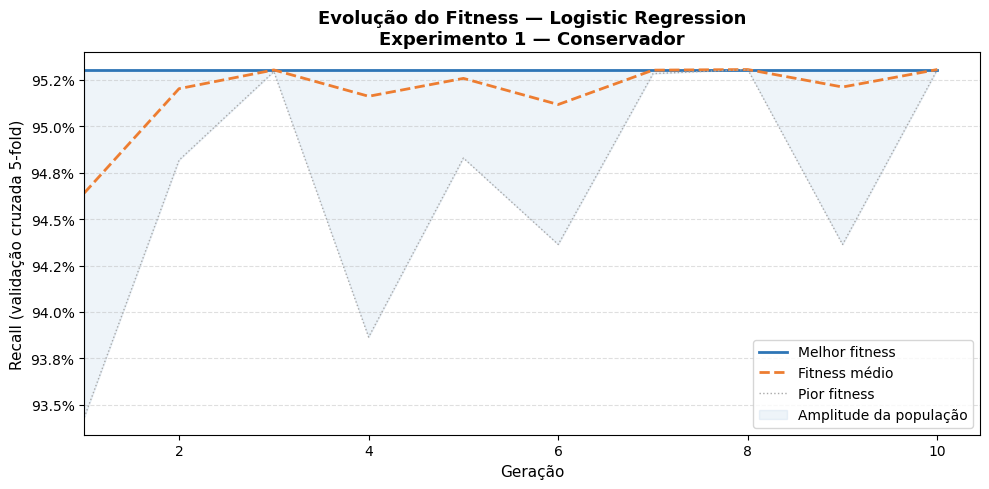


Rodando AG para: random_forest | Experimento 1 — Conservador
2026-08-24 17:03:21 | INFO     | src.genetic_algorithm | [AG] Iniciando | modelo=random_forest | pop=10 | gerações=10 | mutação=0.1
2026-08-24 17:03:32 | INFO     | src.genetic_algorithm | [AG] Geração   1/10 | melhor=0.9293 | média=0.9237 | pior=0.9199
2026-08-24 17:03:41 | INFO     | src.genetic_algorithm | [AG] Geração   2/10 | melhor=0.9293 | média=0.9260 | pior=0.9246
2026-08-24 17:03:49 | INFO     | src.genetic_algorithm | [AG] Geração   3/10 | melhor=0.9293 | média=0.9265 | pior=0.9199
2026-08-24 17:03:58 | INFO     | src.genetic_algorithm | [AG] Geração   4/10 | melhor=0.9293 | média=0.9275 | pior=0.9199
2026-08-24 17:04:08 | INFO     | src.genetic_algorithm | [AG] Geração   5/10 | melhor=0.9293 | média=0.9270 | pior=0.9153
2026-08-24 17:04:18 | INFO     | src.genetic_algorithm | [AG] Geração   6/10 | melhor=0.9293 | média=0.9293 | pior=0.9293
2026-08-24 17:04:31 | INFO     | src.genetic_algorithm | [AG] Geração   7/

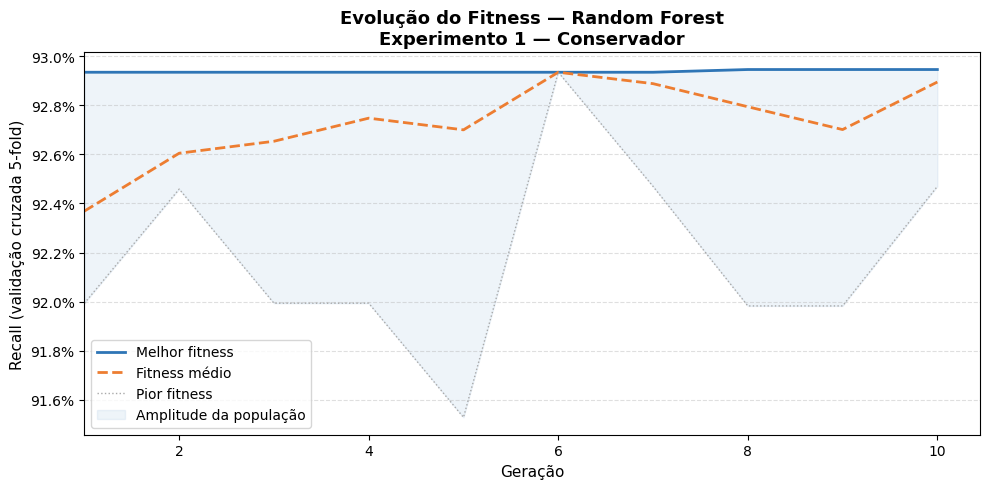


Rodando AG para: knn | Experimento 1 — Conservador
2026-08-24 17:05:21 | INFO     | src.genetic_algorithm | [AG] Iniciando | modelo=knn | pop=10 | gerações=10 | mutação=0.1
2026-08-24 17:05:25 | INFO     | src.genetic_algorithm | [AG] Geração   1/10 | melhor=0.9385 | média=0.9019 | pior=0.8773
2026-08-24 17:05:26 | INFO     | src.genetic_algorithm | [AG] Geração   2/10 | melhor=0.9385 | média=0.9311 | pior=0.9058
2026-08-24 17:05:27 | INFO     | src.genetic_algorithm | [AG] Geração   3/10 | melhor=0.9385 | média=0.9329 | pior=0.8915
2026-08-24 17:05:27 | INFO     | src.genetic_algorithm | [AG] Geração   4/10 | melhor=0.9385 | média=0.9277 | pior=0.8867
2026-08-24 17:05:28 | INFO     | src.genetic_algorithm | [AG] Geração   5/10 | melhor=0.9385 | média=0.9385 | pior=0.9385
2026-08-24 17:05:29 | INFO     | src.genetic_algorithm | [AG] Geração   6/10 | melhor=0.9385 | média=0.9376 | pior=0.9292
2026-08-24 17:05:29 | INFO     | src.genetic_algorithm | [AG] Geração   7/10 | melhor=0.9385 |

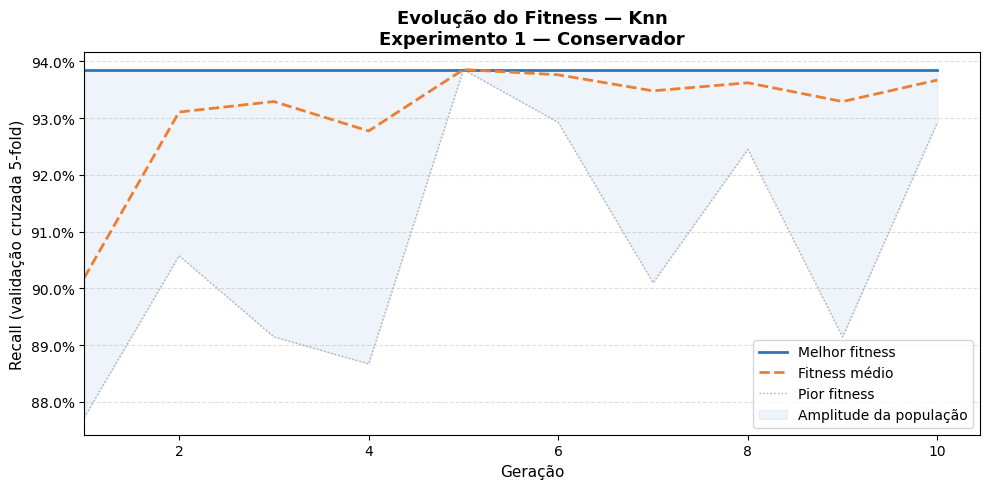


Rodando AG para: svm | Experimento 1 — Conservador
2026-08-24 17:05:32 | INFO     | src.genetic_algorithm | [AG] Iniciando | modelo=svm | pop=10 | gerações=10 | mutação=0.1


c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

2026-08-24 17:05:33 | INFO     | src.genetic_algorithm | [AG] Geração   1/10 | melhor=0.9670 | média=0.8336 | pior=0.3496


c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

2026-08-24 17:05:34 | INFO     | src.genetic_algorithm | [AG] Geração   2/10 | melhor=0.9670 | média=0.9312 | pior=0.8963


...

c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

2026-08-24 17:05:39 | INFO     | src.genetic_algorithm | [AG] Geração  10/10 | melhor=0.9670 | média=0.9627 | pior=0.9245


c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

2026-08-24 17:05:40 | INFO     | src.genetic_algorithm | [AG] Concluído em 7.8s | melhor recall=0.9670 | baseline=0.9576 | ganho=+0.0094
2026-08-24 17:05:40 | INFO     | src.genetic_algorithm | [AG] Resultado salvo em ..\experiments\experiment_1\results\svm_result.json


c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

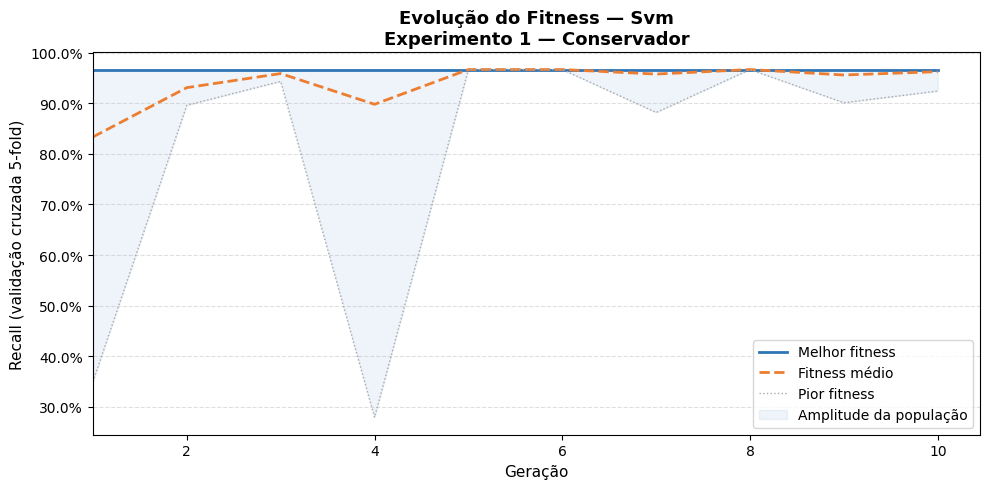


Experimento 1 concluído.


In [4]:
exp = EXPERIMENTS[0]
results_exp1 = []

for model_name in MODELS:
    print(f"\n{'='*60}")
    print(f"Rodando AG para: {model_name} | {exp['label']}")
    print(f"{'='*60}")

    result = run_genetic_algorithm(
        model_name=model_name,
        X=X, y=y,
        baseline_fitness=BASELINES[model_name],
        output_dir=exp["folder"] / "results",
        **exp["config"]
    )
    results_exp1.append(result)

    plot_evolution(
        history=result.history,
        model_name=model_name,
        experiment_label=exp["label"],
        output_path=exp["folder"] / "figures" / f"evolution_{model_name}.png"
    )

print("\nExperimento 1 concluído.")

Resultados — Experimento 1

In [5]:
build_summary_table(results_exp1)

,Modelo,Pop.,Gerações,Mutação,Baseline (Recall),AG melhor (Recall),Ganho,Tempo (s)
0,Logistic Regression,10,10,0.1,0.9440,0.9530,+0.0090,2.53
1,Random Forest,10,10,0.1,0.9340,0.9295,-0.0045,119.86
2,Knn,10,10,0.1,0.9250,0.9385,+0.0135,11.24
3,Svm,10,10,0.1,0.9576,0.9670,+0.0094,7.80


Experimento 2 — Configuração Balanceada: População média (20), gerações moderadas (20), mutação média (20%).

Utilizei a configuração padrão recomendada para problemas de otimização de hiperparâmetros com AGs. Equilibra exploração do espaço de busca com velocidade de convergência.



Rodando AG para: logistic_regression | Experimento 2 — Balanceado
2026-08-24 17:28:27 | INFO     | src.genetic_algorithm | [AG] Iniciando | modelo=logistic_regression | pop=20 | gerações=20 | mutação=0.2
2026-08-24 17:28:28 | INFO     | src.genetic_algorithm | [AG] Geração   1/20 | melhor=0.9576 | média=0.9483 | pior=0.9343
2026-08-24 17:28:29 | INFO     | src.genetic_algorithm | [AG] Geração   2/20 | melhor=0.9576 | média=0.9527 | pior=0.9435
2026-08-24 17:28:30 | INFO     | src.genetic_algorithm | [AG] Geração   3/20 | melhor=0.9576 | média=0.9480 | pior=0.8442
2026-08-24 17:28:31 | INFO     | src.genetic_algorithm | [AG] Geração   4/20 | melhor=0.9576 | média=0.9555 | pior=0.9435
2026-08-24 17:28:32 | INFO     | src.genetic_algorithm | [AG] Geração   5/20 | melhor=0.9576 | média=0.9538 | pior=0.9244
2026-08-24 17:28:34 | INFO     | src.genetic_algorithm | [AG] Geração   6/20 | melhor=0.9577 | média=0.9548 | pior=0.9388
2026-08-24 17:28:35 | INFO     | src.genetic_algorithm | [AG] G

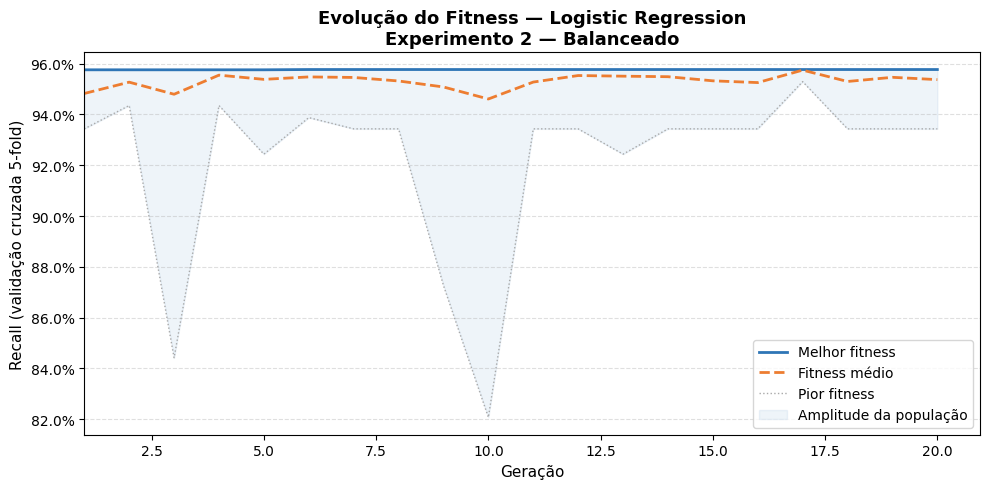


Rodando AG para: random_forest | Experimento 2 — Balanceado
2026-08-24 17:28:48 | INFO     | src.genetic_algorithm | [AG] Iniciando | modelo=random_forest | pop=20 | gerações=20 | mutação=0.2
2026-08-24 17:29:18 | INFO     | src.genetic_algorithm | [AG] Geração   1/20 | melhor=0.9340 | média=0.9237 | pior=0.9153
2026-08-24 17:29:43 | INFO     | src.genetic_algorithm | [AG] Geração   2/20 | melhor=0.9340 | média=0.9240 | pior=0.9152
2026-08-24 17:30:12 | INFO     | src.genetic_algorithm | [AG] Geração   3/20 | melhor=0.9340 | média=0.9263 | pior=0.9153
2026-08-24 17:30:37 | INFO     | src.genetic_algorithm | [AG] Geração   4/20 | melhor=0.9340 | média=0.9279 | pior=0.9199
2026-08-24 17:31:04 | INFO     | src.genetic_algorithm | [AG] Geração   5/20 | melhor=0.9386 | média=0.9293 | pior=0.9153
2026-08-24 17:31:28 | INFO     | src.genetic_algorithm | [AG] Geração   6/20 | melhor=0.9389 | média=0.9303 | pior=0.9199
2026-08-24 17:31:52 | INFO     | src.genetic_algorithm | [AG] Geração   7/2

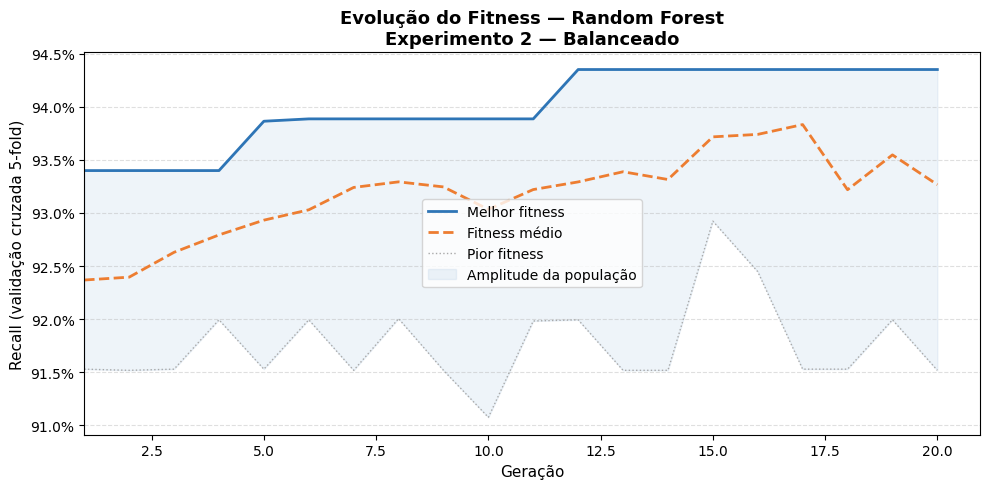


Rodando AG para: knn | Experimento 2 — Balanceado
2026-08-24 17:36:41 | INFO     | src.genetic_algorithm | [AG] Iniciando | modelo=knn | pop=20 | gerações=20 | mutação=0.2
2026-08-24 17:36:43 | INFO     | src.genetic_algorithm | [AG] Geração   1/20 | melhor=0.9385 | média=0.8988 | pior=0.8773
2026-08-24 17:36:44 | INFO     | src.genetic_algorithm | [AG] Geração   2/20 | melhor=0.9385 | média=0.9219 | pior=0.8822
2026-08-24 17:36:46 | INFO     | src.genetic_algorithm | [AG] Geração   3/20 | melhor=0.9385 | média=0.9240 | pior=0.8867
2026-08-24 17:36:48 | INFO     | src.genetic_algorithm | [AG] Geração   4/20 | melhor=0.9385 | média=0.9313 | pior=0.8822
2026-08-24 17:36:50 | INFO     | src.genetic_algorithm | [AG] Geração   5/20 | melhor=0.9385 | média=0.9331 | pior=0.8867
2026-08-24 17:36:51 | INFO     | src.genetic_algorithm | [AG] Geração   6/20 | melhor=0.9385 | média=0.9346 | pior=0.8774
2026-08-24 17:36:52 | INFO     | src.genetic_algorithm | [AG] Geração   7/20 | melhor=0.9385 | 

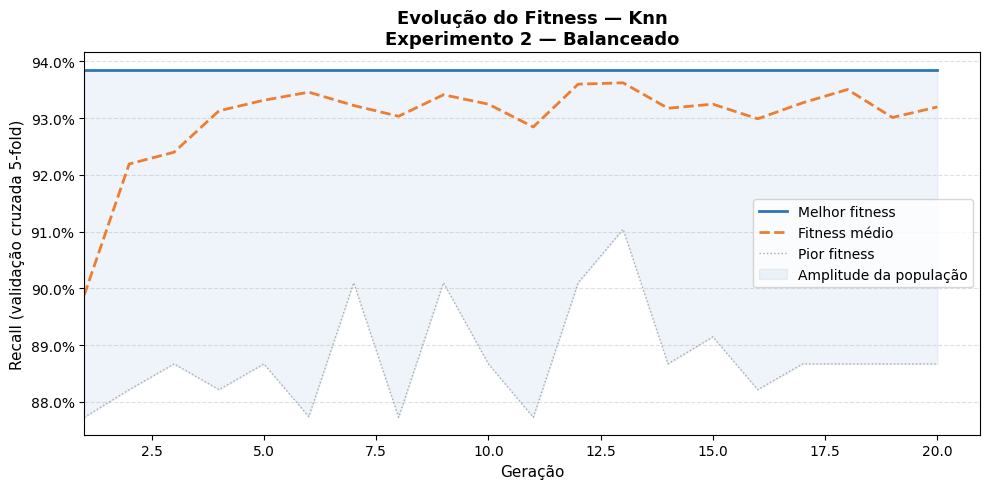


Rodando AG para: svm | Experimento 2 — Balanceado
2026-08-24 17:37:13 | INFO     | src.genetic_algorithm | [AG] Iniciando | modelo=svm | pop=20 | gerações=20 | mutação=0.2


c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

2026-08-24 17:37:16 | INFO     | src.genetic_algorithm | [AG] Geração   1/20 | melhor=0.9670 | média=0.8407 | pior=0.3496


c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

2026-08-24 17:37:17 | INFO     | src.genetic_algorithm | [AG] Geração   2/20 | melhor=0.9670 | média=0.9237 | pior=0.7786


...

c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

2026-08-24 17:37:55 | INFO     | src.genetic_algorithm | [AG] Geração  20/20 | melhor=0.9717 | média=0.9597 | pior=0.8776


c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

2026-08-24 17:37:57 | INFO     | src.genetic_algorithm | [AG] Concluído em 43.18s | melhor recall=0.9717 | baseline=0.9576 | ganho=+0.0141
2026-08-24 17:37:57 | INFO     | src.genetic_algorithm | [AG] Resultado salvo em ..\experiments\experiment_2\results\svm_result.json


c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


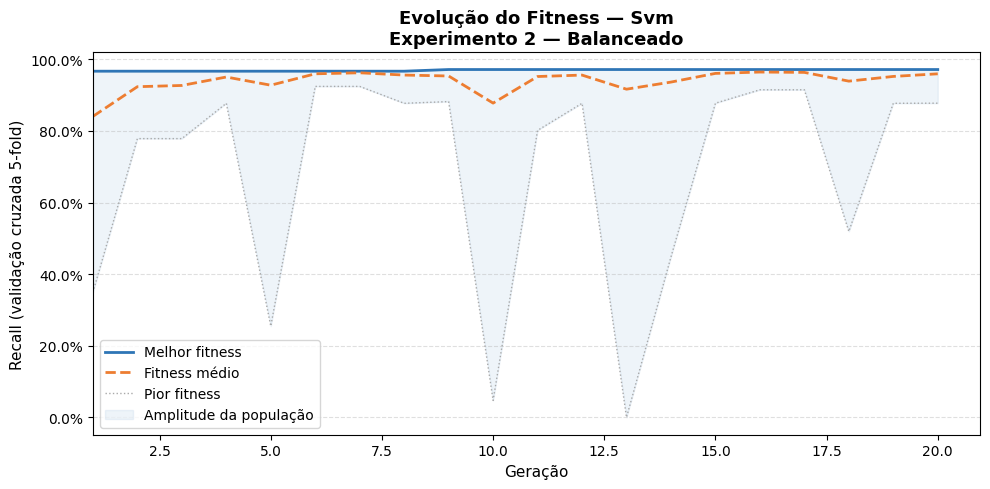


Experimento 2 concluído.


In [6]:
exp = EXPERIMENTS[1]
results_exp2 = []

for model_name in MODELS:
    print(f"\n{'='*60}")
    print(f"Rodando AG para: {model_name} | {exp['label']}")
    print(f"{'='*60}")

    result = run_genetic_algorithm(
        model_name=model_name,
        X=X, y=y,
        baseline_fitness=BASELINES[model_name],
        output_dir=exp["folder"] / "results",
        **exp["config"]
    )
    results_exp2.append(result)

    plot_evolution(
        history=result.history,
        model_name=model_name,
        experiment_label=exp["label"],
        output_path=exp["folder"] / "figures" / f"evolution_{model_name}.png"
    )

print("\nExperimento 2 concluído.")

In [7]:
build_summary_table(results_exp2)


,Modelo,Pop.,Gerações,Mutação,Baseline (Recall),AG melhor (Recall),Ganho,Tempo (s)
0,Logistic Regression,20,20,0.2,0.9440,0.9577,+0.0137,19.83
1,Random Forest,20,20,0.2,0.9340,0.9435,+0.0095,472.76
2,Knn,20,20,0.2,0.9250,0.9385,+0.0135,32.03
3,Svm,20,20,0.2,0.9576,0.9717,+0.0141,43.18


Experimento 3 — Configuração Exploratória: População grande (30), muitas gerações (30), mutação alta (30%).
Alta mutação aumenta a diversidade genética e a exploração do espaço de busca, resultando em mais tempo de execução. Favorece encontrar soluções em regiões do espaço ainda não exploradas pelos exprimentos anteriores.


Rodando AG para: logistic_regression | Experimento 3 — Exploratório
2026-08-24 17:50:50 | INFO     | src.genetic_algorithm | [AG] Iniciando | modelo=logistic_regression | pop=30 | gerações=30 | mutação=0.3
2026-08-24 17:50:51 | INFO     | src.genetic_algorithm | [AG] Geração   1/30 | melhor=0.9576 | média=0.9462 | pior=0.8679
2026-08-24 17:50:52 | INFO     | src.genetic_algorithm | [AG] Geração   2/30 | melhor=0.9577 | média=0.9389 | pior=0.7643
2026-08-24 17:50:53 | INFO     | src.genetic_algorithm | [AG] Geração   3/30 | melhor=0.9577 | média=0.9515 | pior=0.9200
2026-08-24 17:50:54 | INFO     | src.genetic_algorithm | [AG] Geração   4/30 | melhor=0.9577 | média=0.9488 | pior=0.8631
2026-08-24 17:50:55 | INFO     | src.genetic_algorithm | [AG] Geração   5/30 | melhor=0.9577 | média=0.9439 | pior=0.8347
2026-08-24 17:50:56 | INFO     | src.genetic_algorithm | [AG] Geração   6/30 | melhor=0.9577 | média=0.9550 | pior=0.9343
2026-08-24 17:50:58 | INFO     | src.genetic_algorithm | [AG]

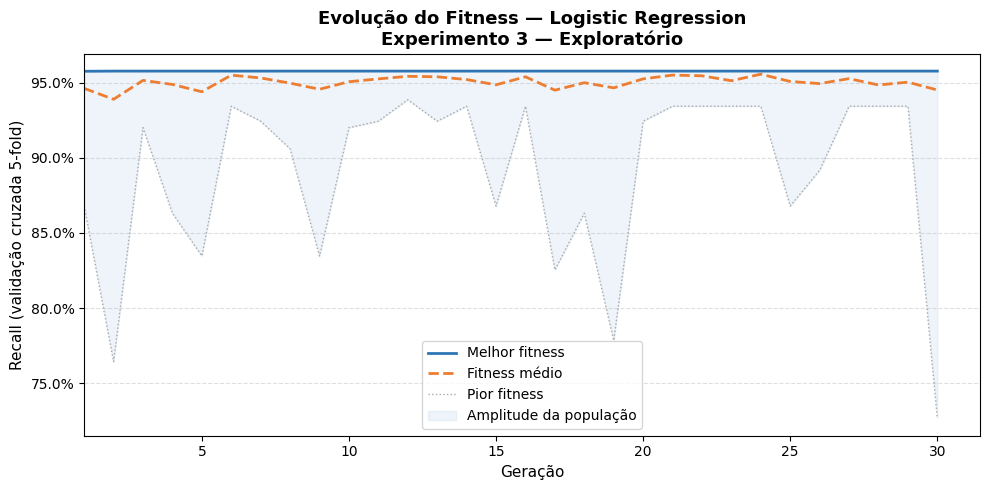


Rodando AG para: random_forest | Experimento 3 — Exploratório
2026-08-24 17:51:24 | INFO     | src.genetic_algorithm | [AG] Iniciando | modelo=random_forest | pop=30 | gerações=30 | mutação=0.3
2026-08-24 17:52:28 | INFO     | src.genetic_algorithm | [AG] Geração   1/30 | melhor=0.9386 | média=0.9240 | pior=0.9153
2026-08-24 17:53:16 | INFO     | src.genetic_algorithm | [AG] Geração   2/30 | melhor=0.9386 | média=0.9249 | pior=0.9106
2026-08-24 17:54:03 | INFO     | src.genetic_algorithm | [AG] Geração   3/30 | melhor=0.9386 | média=0.9253 | pior=0.9105
2026-08-24 17:54:31 | INFO     | src.genetic_algorithm | [AG] Geração   4/30 | melhor=0.9434 | média=0.9276 | pior=0.9105
2026-08-24 17:55:01 | INFO     | src.genetic_algorithm | [AG] Geração   5/30 | melhor=0.9434 | média=0.9299 | pior=0.9153
2026-08-24 17:55:29 | INFO     | src.genetic_algorithm | [AG] Geração   6/30 | melhor=0.9434 | média=0.9298 | pior=0.9104
2026-08-24 17:56:00 | INFO     | src.genetic_algorithm | [AG] Geração   7

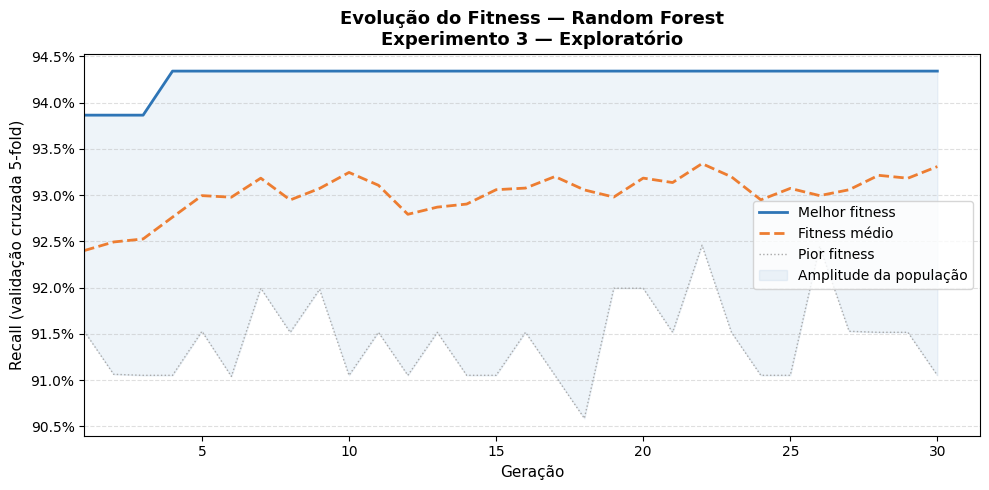


Rodando AG para: knn | Experimento 3 — Exploratório
2026-08-24 18:11:08 | INFO     | src.genetic_algorithm | [AG] Iniciando | modelo=knn | pop=30 | gerações=30 | mutação=0.3
2026-08-24 18:11:10 | INFO     | src.genetic_algorithm | [AG] Geração   1/30 | melhor=0.9385 | média=0.8975 | pior=0.8726
2026-08-24 18:11:12 | INFO     | src.genetic_algorithm | [AG] Geração   2/30 | melhor=0.9385 | média=0.9119 | pior=0.8773
2026-08-24 18:11:14 | INFO     | src.genetic_algorithm | [AG] Geração   3/30 | melhor=0.9385 | média=0.9212 | pior=0.8774
2026-08-24 18:11:16 | INFO     | src.genetic_algorithm | [AG] Geração   4/30 | melhor=0.9385 | média=0.9253 | pior=0.8867
2026-08-24 18:11:19 | INFO     | src.genetic_algorithm | [AG] Geração   5/30 | melhor=0.9385 | média=0.9205 | pior=0.8773
2026-08-24 18:11:21 | INFO     | src.genetic_algorithm | [AG] Geração   6/30 | melhor=0.9385 | média=0.9219 | pior=0.8821
2026-08-24 18:11:24 | INFO     | src.genetic_algorithm | [AG] Geração   7/30 | melhor=0.9385 

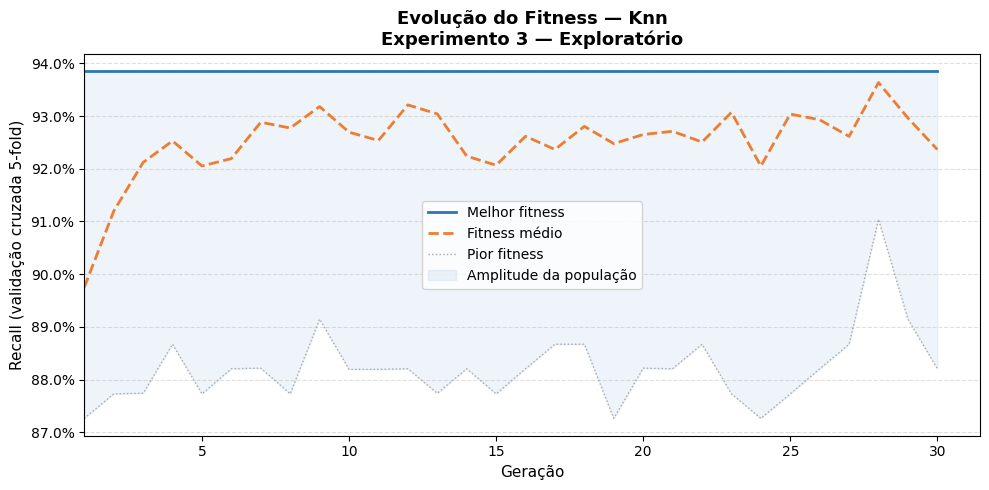


Rodando AG para: svm | Experimento 3 — Exploratório
2026-08-24 18:12:18 | INFO     | src.genetic_algorithm | [AG] Iniciando | modelo=svm | pop=30 | gerações=30 | mutação=0.3


c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

2026-08-24 18:12:22 | INFO     | src.genetic_algorithm | [AG] Geração   1/30 | melhor=0.9670 | média=0.8594 | pior=0.3496


c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

2026-08-24 18:12:27 | INFO     | src.genetic_algorithm | [AG] Geração   2/30 | melhor=0.9670 | média=0.8842 | pior=0.2318


...

c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

2026-08-24 18:14:18 | INFO     | src.genetic_algorithm | [AG] Geração  30/30 | melhor=0.9717 | média=0.8995 | pior=0.0000


c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

2026-08-24 18:14:21 | INFO     | src.genetic_algorithm | [AG] Concluído em 123.14s | melhor recall=0.9717 | baseline=0.9576 | ganho=+0.0141
2026-08-24 18:14:21 | INFO     | src.genetic_algorithm | [AG] Resultado salvo em ..\experiments\experiment_3\results\svm_result.json


c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Dev\IA-For-Devs\fase-01\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will 

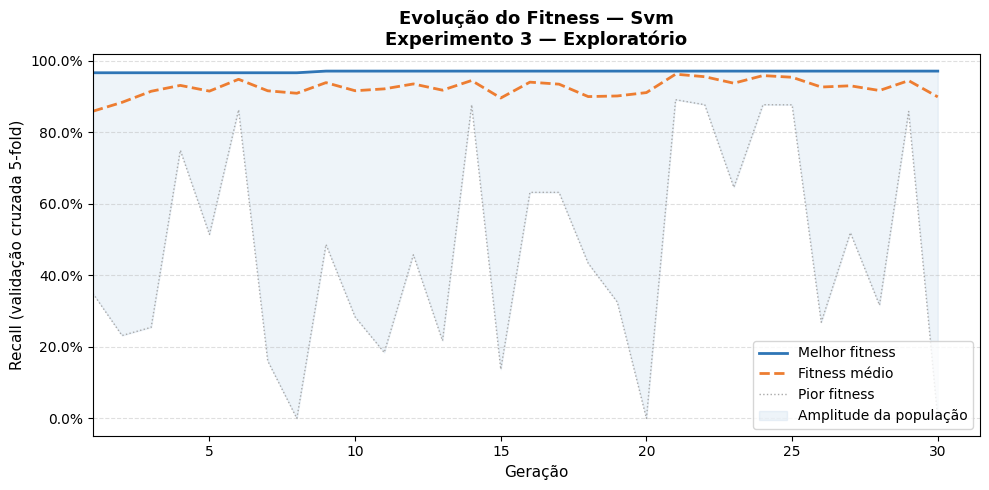


Experimento 3 concluído.


In [8]:
exp = EXPERIMENTS[2]
results_exp3 = []

for model_name in MODELS:
    print(f"\n{'='*60}")
    print(f"Rodando AG para: {model_name} | {exp['label']}")
    print(f"{'='*60}")

    result = run_genetic_algorithm(
        model_name=model_name,
        X=X, y=y,
        baseline_fitness=BASELINES[model_name],
        output_dir=exp["folder"] / "results",
        **exp["config"]
    )
    results_exp3.append(result)

    plot_evolution(
        history=result.history,
        model_name=model_name,
        experiment_label=exp["label"],
        output_path=exp["folder"] / "figures" / f"evolution_{model_name}.png"
    )

print("\nExperimento 3 concluído.")


In [9]:
build_summary_table(results_exp3)


,Modelo,Pop.,Gerações,Mutação,Baseline (Recall),AG melhor (Recall),Ganho,Tempo (s)
0,Logistic Regression,30,30,0.3,0.9440,0.9577,+0.0137,34.19
1,Random Forest,30,30,0.3,0.9340,0.9434,+0.0094,1183.36
2,Knn,30,30,0.3,0.9250,0.9385,+0.0135,69.37
3,Svm,30,30,0.3,0.9576,0.9717,+0.0141,123.14


Comparação: Baseline vs. Melhor resultado por experimento

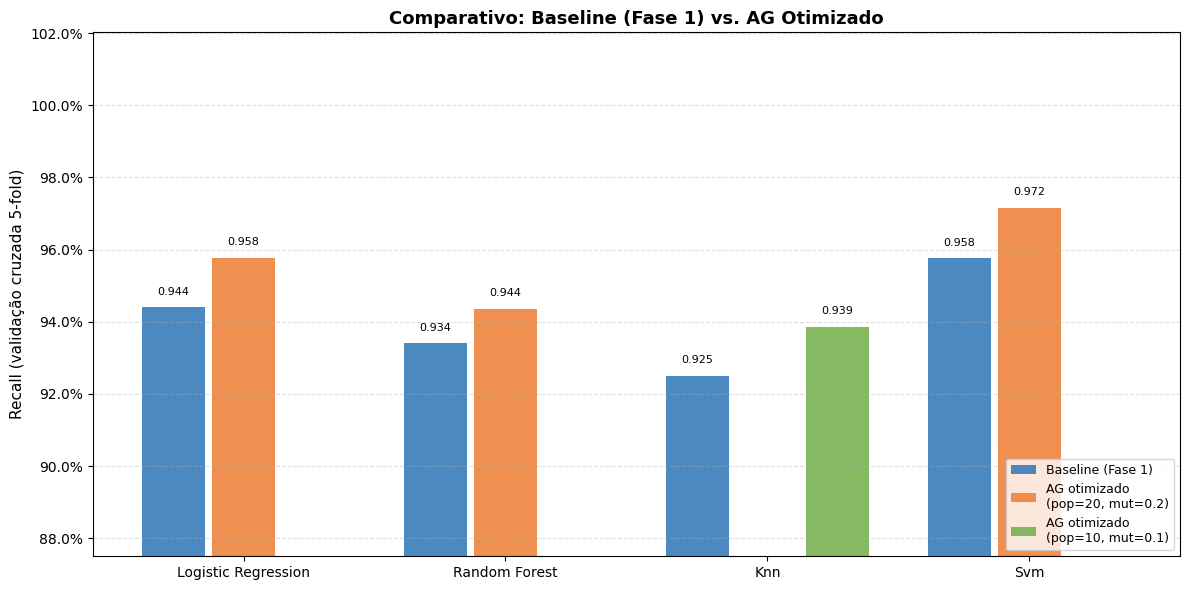

In [10]:
# Relizar a captura do melhor resultado de cada modelo através dos 3 experimentos
best_per_model = {}
for model_name in MODELS:
    candidates = []
    for results in [results_exp1, results_exp2, results_exp3]:
        for r in results:
            if r.model_name == model_name and r.best_individual:
                candidates.append(r)
    if candidates:
        best_per_model[model_name] = max(candidates, key=lambda r: r.best_individual.fitness)

plot_comparison(
    results=list(best_per_model.values()),
    output_path=Path("../outputs/figures/comparativo_final.png")
)

Tabela comparativa final

In [11]:
# Tabela com baseline vs melhor AG para cada modelo
rows = []
for model_name in MODELS:
    if model_name in best_per_model:
        r = best_per_model[model_name]
        best = r.best_individual.fitness
        baseline = r.baseline_fitness
        rows.append({
            "Modelo": model_name.replace("_", " ").title(),
            "Baseline Fase 1 (Recall)": f"{baseline:.4f}",
            "AG Otimizado (Recall)":    f"{best:.4f}",
            "Ganho Absoluto":           f"{best - baseline:+.4f}",
            "Melhor Experimento":       f"Pop={r.config['population_size']}, Mut={r.config['mutation_rate']}",
            "Melhores Hiperparâmetros": str(r.best_individual.genes),
        })

pd.DataFrame(rows)

,Modelo,Baseline Fase 1 (Recall),AG Otimizado (Recall),Ganho Absoluto,Melhor Experimento,Melhores Hiperparâmetros
0,Logistic Regression,0.9440,0.9577,+0.0137,"Pop=20, Mut=0.2","{'C': 0.13106205504918578, 'solver': 'liblinea..."
1,Random Forest,0.9340,0.9435,+0.0095,"Pop=20, Mut=0.2","{'n_estimators': 115, 'max_depth': 7, 'min_sam..."
2,Knn,0.9250,0.9385,+0.0135,"Pop=10, Mut=0.1","{'n_neighbors': 3, 'weights': 'distance', 'met..."
3,Svm,0.9576,0.9717,+0.0141,"Pop=20, Mut=0.2","{'C': 5.9451371557227315, 'kernel': 'rbf', 'ga..."
